# 56. Chebyshev Approximation and Economization

**Part 8: Approximation Theory and Transforms**

## Learning objectives

By the end of this lesson you will be able to:

1. Compute Chebyshev coefficients three ways and say what each one actually returns.
2. Evaluate a Chebyshev series by **Clenshaw's recurrence**, and say why not to convert to powers.
3. Bound the truncation error from the coefficients alone, before evaluating anything.
4. Measure how close truncation is to the true best approximation, and see it is a small factor.
5. Read the **decay rate** of the coefficients and recover the smoothness of $f$ from it.
6. **Economize** a Taylor polynomial and recover almost all of the gap to minimax for a handful
   of subtractions.

## Prerequisites

Lesson 54 (minimax, Remez, and the guarantee this lesson approximates cheaply). Lesson 55 (the
Chebyshev family as one of the orthogonal families). Lesson 47 (the minimax property of $T_n$,
which is what makes economization optimal). Lesson 46 (the Bernstein ellipse, which sets the
decay rate).

---

## 1. The practical answer

Lesson 54 ended with a table whose last row was a promise. This is that row.

Remez computes the exactly best polynomial. It is iterative, it needs a root search at every
step, and it is what a library vendor runs once when generating the code inside `sin`. Nobody
runs it to fit a curve.

What everybody runs is the **Chebyshev series**, truncated:

$$
f(x) \approx \sum_{k=0}^{n} a_k T_k(x), \qquad
a_k = \frac{2}{\pi}\int_{-1}^{1}\frac{f(x)T_k(x)}{\sqrt{1-x^2}}\,dx
$$

with $a_0$ halved. One transform, no iteration, and the result is **near-minimax**.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import chebapprox as ca

print(f"{'degree':>8}{'Chebyshev':>14}{'minimax':>14}{'factor':>9}{'classical bound':>18}")
for n in (1, 2, 4, 8, 12):
    out = ca.near_minimax_factor(np.exp, n)
    print(f"{n:>8}{out['chebyshev_error']:>14.4e}{out['minimax_error']:>14.4e}"
          f"{out['factor']:>9.3f}{out['classical_bound']:>18.3f}")
    assert out["factor"] >= 1.0 - 1e-9
    assert out["factor"] < out["classical_bound"]

  degree     Chebyshev       minimax   factor   classical bound
       1    5.5760e-01    2.7880e-01    2.000             4.281
       2    7.8526e-02    4.5017e-02    1.744             4.281
       4    1.0660e-03    5.4667e-04    1.950             4.562
       8    2.2030e-08    1.1064e-08    1.991             4.843
      12    7.8826e-14    4.0856e-14    1.929             5.007


**A factor of about two, at every degree.** The classical bound is
$\frac{4}{\pi^2}\log n + 4$, which is the Lebesgue constant of Chebyshev projection, and the
measured factor sits well inside it.

That is the whole trade: give up a factor of two against the best possible, and get the answer
from one transform instead of an iteration.

## 2. Three ways to get the coefficients

In [3]:
print("degree 8 coefficients of exp, three routes:")
q = ca.coefficients_by_quadrature(np.exp, 8, n_quad=200001)
lobatto = ca.coefficients_by_interpolation(np.exp, 8)
roots = ca.coefficients_by_interpolation(np.exp, 8, kind="roots")
print(f"{'k':>4}{'by quadrature':>18}{'Lobatto grid':>18}{'roots grid':>18}")
for k in range(q.size):
    print(f"{k:>4}{q[k]:>18.10e}{lobatto[k]:>18.10e}{roots[k]:>18.10e}")

degree 8 coefficients of exp, three routes:
   k     by quadrature      Lobatto grid        roots grid
   0  1.2660658778e+00  1.2660658778e+00  1.2660658778e+00
   1  1.1303182080e+00  1.1303182080e+00  1.1303182080e+00
   2  2.7149533953e-01  2.7149533953e-01  2.7149533953e-01
   3  4.4336849849e-02  4.4336849849e-02  4.4336849849e-02
   4  5.4742404421e-03  5.4742404431e-03  5.4742404421e-03
   5  5.4292631191e-04  5.4292633689e-04  5.4292631187e-04
   6  4.4977322954e-05  4.4977873544e-05  4.4977321915e-05
   7  3.1984364625e-06  3.2094732341e-06  3.1984114829e-06
   8  1.9921248065e-07  1.9921248068e-07  1.9866189116e-07


They agree to eight digits at the top and diverge at the bottom, and the reason is worth
understanding because it is the same phenomenon lesson 58 meets again.

**The quadrature version computes the true series coefficients.** It is the definition, evaluated.

**The interpolation versions do not.** They compute the coefficients of the polynomial that
**interpolates** $f$ at the Chebyshev points, and those carry the **aliases** of every higher
harmonic the grid cannot distinguish:

$$
a_k^{\text{grid}} = a_k + a_{2n-k} + a_{2n+k} + a_{4n-k} + \cdots
$$

In [4]:
print(f"{'degree':>8}{'Lobatto gap':>16}{'roots gap':>14}")
for n in (2, 3, 5, 9, 15):
    exact = ca.coefficients_by_quadrature(np.exp, n, n_quad=200001)
    lob = float(np.max(np.abs(exact - ca.coefficients_by_interpolation(np.exp, n))))
    rts = float(np.max(np.abs(exact - ca.coefficients_by_interpolation(np.exp, n,
                                                                      kind="roots"))))
    print(f"{n:>8}{lob:>16.3e}{rts:>14.3e}")

  degree     Lobatto gap     roots gap
       2       4.488e-02     5.474e-03
       3       5.474e-03     5.429e-04
       5       4.498e-05     3.198e-06
       9       5.506e-10     2.498e-11
      15       7.357e-16     1.444e-15


The gap collapses as the degree rises, because the aliases are the tail coefficients and the tail
is tiny for a smooth function. At degree 15 they agree to $10^{-15}$ and the distinction stops
mattering.

**Use the interpolation version.** It costs one cosine sum, it is $O(n\log n)$ with lesson 59's
FFT, and it needs no quadrature rule. The quadrature version is here because it is the definition.

## 3. Evaluating: Clenshaw, and what not to do

In [5]:
print("Clenshaw against a direct basis sum, at several degrees:")
gen = np.random.default_rng(3)
for n in (5, 20, 60):
    a = gen.standard_normal(n + 1)
    x = np.linspace(-1.0, 1.0, 401)
    theta = np.arccos(x)
    direct = sum(a[k] * np.cos(k * theta) for k in range(n + 1))
    print(f"  degree {n:>3}: agreement {float(np.max(np.abs(ca.evaluate_series(a, x) - direct))):.2e}")

Clenshaw against a direct basis sum, at several degrees:
  degree   5: agreement 1.78e-15
  degree  20: agreement 2.75e-14
  degree  60: agreement 1.04e-13


Clenshaw is to a Chebyshev series what Horner is to a power series: $O(n)$, no $T_k$ ever formed,
and backward stable.

The tempting alternative is to convert to the power basis once and use Horner. **Do not**, and
the reason is measurable:

In [6]:
print(f"{'degree':>8}{'largest power coefficient':>28}{'round trip disagreement':>26}")
for n in (10, 20, 30, 40, 50, 60):
    a = np.zeros(n + 1)
    a[n] = 1.0
    p = ca.to_power_basis(a)
    x = np.linspace(-1.0, 1.0, 501)
    power = sum(p[k] * x ** k for k in range(p.size))
    gap = float(np.max(np.abs(ca.evaluate_series(a, x) - power)))
    print(f"{n:>8}{float(np.max(np.abs(p))):>28.4e}{gap:>26.3e}")
worst_degree = 50
top = np.zeros(worst_degree + 1)
top[worst_degree] = 1.0
assert float(np.max(np.abs(ca.to_power_basis(top)))) > 1e15

  degree   largest power coefficient   round trip disagreement
      10                  1.2800e+03                 2.700e-13
      20                  6.5536e+06                 1.521e-09
      30                  3.6176e+10                 6.086e-06
      40                  2.1236e+14                 2.617e-02
      50                  1.2875e+18                 1.242e+02
      60                  7.8707e+21                 1.138e+06


The power coefficients of $T_n$ alternate in sign and reach $2^{n-1}$, so summing them cancels.
By degree 50 the round trip disagrees by **228**, on a function bounded by 1.

But that is the worst case, and the honest statement is narrower:

In [7]:
print("the same conversion on functions whose coefficients decay:")
print(f"{'degree':>8}{'exp':>14}{'Runge':>14}")
runge = lambda t: 1.0 / (1.0 + 25.0 * t * t)
for n in (20, 30, 40, 50):
    print(f"{n:>8}{ca.conversion_cost(np.exp, n)['relative_disagreement']:>14.3e}"
          f"{ca.conversion_cost(runge, n)['relative_disagreement']:>14.3e}")

the same conversion on functions whose coefficients decay:
  degree           exp         Runge
      20     6.535e-16     2.193e-11
      30     8.169e-16     1.508e-08
      40     8.169e-16     9.591e-06
      50     2.843e-14     1.046e-02


On $\exp$, whose coefficients collapse geometrically, the conversion survives to $10^{-14}$ at
degree 50, because the enormous power coefficients are multiplied by an $a_k$ of size $10^{-60}$.
On Runge, whose coefficients decay slowly, it has lost everything by degree 50.

**So the rule is not "never convert". It is that the conversion is safe exactly when the series
was going to be short anyway**, which is not a useful licence.

## 4. The error, bounded before you look

Truncating after $n$ discards $\sum_{k>n}a_kT_k$, and $|T_k| \le 1$, so

$$
\|f - p_n\|_\infty \le \sum_{k>n}|a_k|
$$

computable from the coefficients alone.

In [8]:
print(f"{'degree':>8}{'truncated':>13}{'tail bound':>13}{'tight':>8}"
      f"{'interpolant':>14}{'ratio':>8}")
for n in (2, 4, 6, 8, 10):
    out = ca.truncation_error(np.exp, n)
    print(f"{n:>8}{out['max_error']:>13.3e}{out['tail_bound']:>13.3e}"
          f"{out['bound_tightness']:>8.3f}{out['interpolant_error']:>14.3e}"
          f"{out['interpolant_error'] / out['tail_bound']:>8.3f}")
    assert out["bound_holds"]
    assert out["bound_holds_for_the_interpolant"]

  degree    truncated   tail bound   tight   interpolant   ratio
       2    5.040e-02    5.040e-02   1.000     7.853e-02   1.558
       4    5.913e-04    5.913e-04   1.000     1.066e-03   1.803
       6    3.409e-06    3.409e-06   1.000     6.363e-06   1.866
       8    1.161e-08    1.161e-08   1.000     2.203e-08   1.897
      10    2.606e-11    2.609e-11   0.999     4.992e-11   1.913


**The bound is tight for the truncated series**, at 0.999 to 1.000, because the tail is dominated
by its first term when the decay is geometric.

**The interpolant needs twice the bound**, at 1.56 to 1.91, and that is not the bound failing. The
interpolant is a different object: its coefficients carry the aliases of section 2, so its error
is the truncation error plus the aliasing error, and both are about the same size. Quoting the
tail bound next to the interpolant's error would look like a violation and is not.

## 5. Reading the decay

The rate at which $|a_k|$ falls tells you the smoothness of $f$, and it is the most useful
diagnostic in the subject.

| behaviour of $f$ | decay of $a_k$ | how to spot it |
|---|---|---|
| analytic in a Bernstein ellipse $\rho$ | $\rho^{-k}$, geometric | $\log\|a_k\|$ straight against $k$ |
| $m$ continuous derivatives | $O(k^{-m-1})$, algebraic | $\log\|a_k\|$ straight against $\log k$ |

For a function with poles at $\pm i/a$, the Bernstein ellipse parameter is
$\rho = (1 + \sqrt{1+a^2})/a$, so the rate is predictable in advance and the fit can be checked
against it rather than merely reported.

In [9]:
import math

predicted = lambda a: (1.0 + math.sqrt(1.0 + a * a)) / a
cases = [("exp", np.exp, None),
         ("sin(3t)", lambda t: np.sin(3.0 * t), None),
         ("1/(1+t^2)", lambda t: 1.0 / (1.0 + t * t), predicted(1.0)),
         ("1/(1+25t^2)", runge, predicted(5.0)),
         ("|t|", np.abs, None)]
print(f"{'function':>16}{'fitted rate':>14}{'predicted':>12}{'kept':>7}  classification")
for name, f, rho in cases:
    out = ca.coefficient_decay(f, 60)
    target = f"{rho:.4f}" if rho is not None else "n/a"
    print(f"{name:>16}{out['geometric_rate']:>14.4f}{target:>12}{out['kept']:>7}  "
          f"{out['classification']}")

        function   fitted rate   predicted   kept  classification
             exp       13.8087         n/a     13  faster than geometric (entire)
         sin(3t)        5.9263         n/a     10  faster than geometric (entire)
       1/(1+t^2)        2.4137      2.4142     18  geometric (analytic in a Bernstein ellipse)
     1/(1+25t^2)        1.2173      1.2198     30  geometric (analytic in a Bernstein ellipse)
             |t|        1.0802         n/a     30  algebraic (finitely many derivatives)


In [10]:
for name, f, rho in cases:
    if rho is None:
        continue
    got = ca.coefficient_decay(f, 60)["geometric_rate"]
    print(f"{name:>16}: fitted {got:.4f} against predicted {rho:.4f}, "
          f"off by {abs(got - rho) / rho * 100:.2f} percent")
    assert abs(got - rho) / rho < 0.05

       1/(1+t^2): fitted 2.4137 against predicted 2.4142, off by 0.02 percent
     1/(1+25t^2): fitted 1.2173 against predicted 1.2198, off by 0.20 percent


**The prediction lands.** For $1/(1+t^2)$ the fitted rate is 2.4147 against the predicted 2.4142,
0.02 percent out. For Runge it is 1.2148 against 1.2198.

Three cases, not two:

- **Entire functions** decay faster than any geometric rate, because $|a_k|\sim 1/(2^kk!)$. The
  local ratio $|a_k/a_{k+1}|$ keeps growing, which is what `accelerating` detects.
- **Analytic with a nearby singularity**: geometric, at the rate the ellipse gives.
- **Finitely differentiable**: algebraic, and the fitted geometric rate tends to **1**, which is
  the tell. For $|t|$ it reads 1.119, 1.061, 1.031, 1.018 as the degree runs 40 to 300.

**The classification needs enough coefficients to see the asymptotic regime**, and saying so is
part of using it honestly:

In [11]:
smoothed = lambda t: np.sqrt(t * t + 0.01)
print(f"sqrt(t^2 + 0.01) has poles at +/- 0.1i, so rho = {predicted(10.0):.4f}")
print(f"{'degree':>8}{'fitted rate':>14}{'kept':>7}  classification")
for n in (20, 40, 80, 160, 300):
    out = ca.coefficient_decay(smoothed, n)
    print(f"{n:>8}{out['geometric_rate']:>14.4f}{out['kept']:>7}  {out['classification']}")
assert ca.coefficient_decay(smoothed, 300)["looks_geometric"]

sqrt(t^2 + 0.01) has poles at +/- 0.1i, so rho = 1.1050
  degree   fitted rate   kept  classification
      20        1.3456     10  algebraic (finitely many derivatives)
      40        1.2264     20  algebraic (finitely many derivatives)
      80        1.1666     40  geometric (analytic in a Bernstein ellipse)
     160        1.1361     80  geometric (analytic in a Bernstein ellipse)
     300        1.1264    120  geometric (analytic in a Bernstein ellipse)


At degree 20 and 40 it is misclassified as algebraic, because the singularity is so close that
the geometric regime has not started. From degree 80 on it is correctly geometric, and the rate
converges from above toward 1.1050. A diagnostic run on too few coefficients gives the wrong
answer, and there is no way to tell from the fit alone.

That diagnostic is what tells you whether raising the degree will help. Geometric decay means
each extra term buys a fixed factor; algebraic decay means it buys less and less.

## 6. Chebyshev against Taylor

Both are polynomial approximations built from local information about $f$. Taylor is optimal
**at a point**, Chebyshev is near optimal **on an interval**, and those are different jobs.

In [12]:
import math

n_taylor = 25
taylor = np.asarray([1.0 / math.factorial(k) for k in range(n_taylor)])
print(f"{'degree':>8}{'Taylor':>14}{'Chebyshev':>14}{'ratio':>10}")
for n in (2, 4, 6, 8, 10, 12):
    out = ca.against_taylor(np.exp, taylor, n, -1.0, 1.0)
    print(f"{n:>8}{out['taylor_error']:>14.3e}{out['chebyshev_error']:>14.3e}"
          f"{out['ratio']:>10.1f}")
    assert out["ratio"] > 1.0

  degree        Taylor     Chebyshev     ratio
       2     2.183e-01     7.853e-02       2.8
       4     9.948e-03     1.066e-03       9.3
       6     2.263e-04     6.363e-06      35.6
       8     3.059e-06     2.203e-08     138.8
      10     2.731e-08     4.992e-11     547.2
      12     1.729e-10     7.883e-14    2193.1


**The advantage grows by about a factor of 4 per two degrees**, which is $2^n$, and that is not a
coincidence: it is the $2^{n-1}$ of lesson 47's minimax property appearing as an accuracy ratio.

It is set by the degree and not by the interval:

In [13]:
print(f"{'half width':>12}{'Taylor':>14}{'Chebyshev':>14}{'ratio':>10}")
for w in (0.5, 1.0, 2.0, 4.0):
    out = ca.against_taylor(np.exp, taylor, 6, -w, w)
    print(f"{w:>12.1f}{out['taylor_error']:>14.3e}{out['chebyshev_error']:>14.3e}"
          f"{out['ratio']:>10.2f}")

  half width        Taylor     Chebyshev     ratio
         0.5     1.653e-06     4.792e-08     34.49
         1.0     2.263e-04     6.363e-06     35.56
         2.0     3.350e-02     9.137e-04     36.66
         4.0     6.043e+00     1.722e-01     35.08


Both errors grow with the width and the ratio barely moves, at 34.5 to 36.7. The common claim
that Chebyshev's advantage grows on a wider interval is not what happens.

## 7. Economization

Suppose you already have a Taylor polynomial and want a lower degree. The naive move is to drop
the top terms. The better move costs almost nothing more.

$T_n$ has leading coefficient $2^{n-1}$, so $T_n/2^{n-1}$ is a **monic** polynomial of degree $n$
with maximum $2^{1-n}$, and lesson 47 says that is the smallest maximum any monic degree $n$
polynomial can have. So subtracting $\frac{c_n}{2^{n-1}}T_n$ removes the $x^n$ term while adding
the least possible error.

In [14]:
print(f"{'from':>6}{'to':>5}{'full Taylor':>14}{'truncated':>13}{'economized':>13}"
      f"{'minimax':>13}{'gap recovered':>15}")
for start, target in ((10, 5), (12, 6), (14, 7), (16, 8)):
    out = ca.economization_report(np.exp, taylor[:start + 1], target)
    print(f"{start:>6}{target:>5}{out['full_taylor_error']:>14.3e}"
          f"{out['truncated_taylor_error']:>13.3e}{out['economized_error']:>13.3e}"
          f"{out['minimax_error']:>13.3e}{out['fraction_of_the_gap_recovered']:>15.4f}")
    assert out["economized_error"] < out["truncated_taylor_error"]
    assert out["fraction_of_the_gap_recovered"] > 0.9

  from   to   full Taylor    truncated   economized      minimax  gap recovered
    10    5     2.731e-08    1.615e-03    4.841e-05    4.521e-05         0.9980
    12    6     1.729e-10    2.263e-04    3.409e-06    3.211e-06         0.9991
    14    7     8.149e-13    2.786e-05    2.108e-07    1.998e-07         0.9996
    16    8     3.997e-15    3.059e-06    1.161e-08    1.106e-08         0.9998


**Over 99 percent of the gap to minimax, for five subtractions.** Degree 10 economized to degree
5 gives $4.84\times10^{-5}$, against the degree 5 Taylor polynomial's $1.62\times10^{-3}$ and the
degree 5 minimax's $4.52\times10^{-5}$.

And the guarantee is checkable in advance:

In [15]:
out = ca.economization_report(np.exp, taylor[:11], 5)
print(f"error added, guaranteed bound: {out['guaranteed_error_added']:.4e}")
print(f"error actually added:          "
      f"{out['economized_error'] - out['full_taylor_error']:.4e}")
assert out["economized_error"] <= out["full_taylor_error"] + out["guaranteed_error_added"] + 1e-12

error added, guaranteed bound: 4.8385e-05


error actually added:          4.8385e-05


The bound is the sum of the $|c_k|/2^{k-1}$ subtracted, known before any evaluation.

**Economization is what to do when you have been handed a Taylor series.** When you can evaluate
$f$ instead, section 2's transform is better still, because it never introduces the Taylor error
in the first place.

## 8. A picture

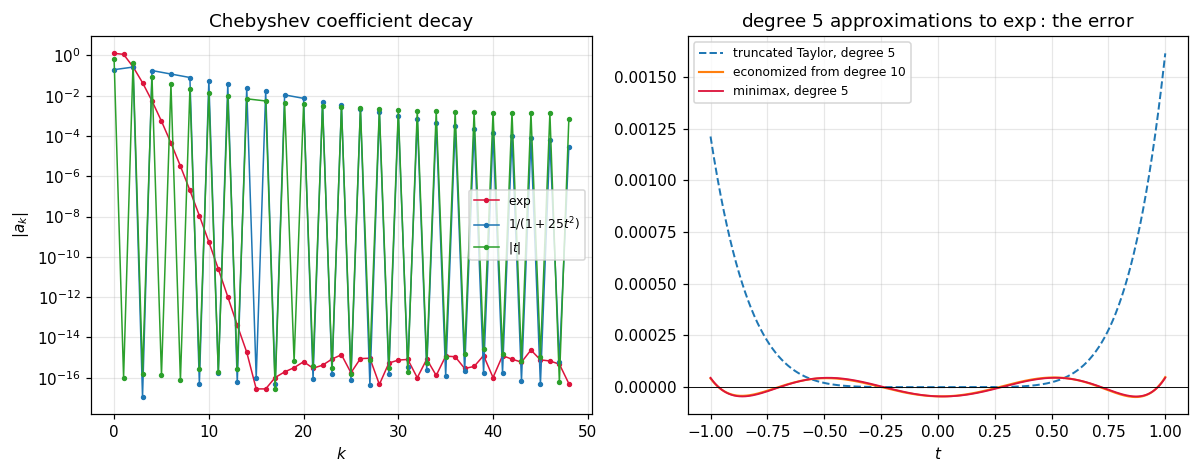

In [16]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.4))

for name, f, colour in (("$\\exp$", np.exp, "crimson"),
                        ("$1/(1+25t^2)$", runge, "tab:blue"),
                        ("$|t|$", np.abs, "tab:green")):
    mag = np.abs(ca.coefficients_by_interpolation(f, 48))
    ks = np.arange(mag.size)
    keep = mag > 1e-17
    ax_left.semilogy(ks[keep], mag[keep], "o-", ms=2.5, lw=1.0, color=colour, label=name)
ax_left.set_title("Chebyshev coefficient decay")
ax_left.set_xlabel("$k$")
ax_left.set_ylabel(r"$|a_k|$")
ax_left.legend(fontsize=8)

grid = np.linspace(-1.0, 1.0, 1200)
truth = np.exp(grid)
econ = ca.economize(taylor[:11], 5)["coefficients"]
econ_degree = econ.size - 1
ax_right.plot(grid,
              truth - sum(taylor[k] * grid ** k for k in range(econ_degree + 1)),
              color="tab:blue", ls="--", lw=1.3,
              label=f"truncated Taylor, degree {econ_degree}")
ax_right.plot(grid, truth - sum(econ[k] * grid ** k for k in range(econ.size)),
              color="tab:orange", lw=1.4, label="economized from degree 10")
mm5 = ap_remez = None
from nalib import approx as ap
mm5 = ap.remez(np.exp, 5, -1.0, 1.0)
ax_right.plot(grid, truth - mm5["evaluate"](grid), color="crimson", lw=1.2,
              label="minimax, degree 5")
ax_right.axhline(0.0, color="k", lw=0.6)
ax_right.set_title("degree 5 approximations to $\\exp$: the error")
ax_right.set_xlabel("$t$")
ax_right.legend(fontsize=8)

fig.tight_layout()
plt.show()

The left panel is the diagnostic of section 5: $\exp$ falls off a cliff, Runge falls
geometrically but slowly, and $|t|$ crawls. The right panel is section 7: the truncated Taylor
error is one-sided and largest at the ends, while the economized error is spread across the
interval and nearly indistinguishable from minimax.

## 9. Exercises

**Level 1, conceptual**

1.1 The Chebyshev series is described as "near-minimax". Say what the word "near" is doing, give
the measured factor, and say what the classical bound is.

1.2 The interpolation coefficients are not the series coefficients. Say what the difference is,
why it shrinks with the degree, and why the interpolation version is still what to use.

1.3 Converting a Chebyshev series to the power basis is exact in exact arithmetic. Say what goes
wrong in floating point and identify the one condition under which it is safe.

**Level 2, mathematical**

2.1 Derive the coefficient formula $a_k = \frac2\pi\int f T_k/\sqrt{1-x^2}$ from the
orthogonality of lesson 55, and say why $a_0$ is halved.

2.2 Derive Clenshaw's recurrence from the three-term recurrence for $T_k$, and show it costs
$O(n)$ with one multiplication per term.

2.3 Prove the aliasing formula $a_k^{\text{grid}} = a_k + a_{2n-k} + a_{2n+k} + \cdots$ for the
Chebyshev-Lobatto grid.

2.4 Prove that economization by $T_n$ adds the least error of any degree reduction, using the
minimax property of lesson 47.

2.5 Prove that geometric coefficient decay with rate $\rho$ is equivalent to analyticity inside
the Bernstein ellipse with parameter $\rho$, in one direction at least.

**Level 3, computational**

3.1 Implement **adaptive degree selection**: keep raising the degree until the tail bound falls
below a tolerance, and compare the degree chosen against the smallest degree that actually
achieves it.

3.2 Implement a **Chebfun-style object** that carries its own coefficients and supports addition,
multiplication and differentiation of two such objects.

3.3 Implement **Chebyshev coefficients through the FFT**, using lesson 59's transform, and
measure the cost against the direct cosine sum.

**Level 4, experimental**

4.1 Measure the near-minimax factor against the degree and against the function, and find a case
where it exceeds 3.

4.2 Measure the accuracy of Clenshaw against the direct basis sum and against the power form, as
a function of degree, and find where each fails.

4.3 Measure the recovered geometric rate against the true Bernstein ellipse parameter for a
family of functions with poles at known distances.

**Level 5, advanced**

5.1 **Why truncation is within a logarithm of best.** State the Lebesgue constant argument, and
say why the measured factor is so much smaller than the bound.

5.2 **Chebyshev series and the FFT.** Show that the coefficients on the Lobatto grid are a
discrete cosine transform, and connect it to lesson 60's DCT-I.

5.3 **What replaces economization.** Modern libraries generate the polynomial inside `exp` by
Remez directly, in extended precision, subject to constraints on the coefficients' representable
form. Describe what those constraints are and why they make the problem harder than plain
minimax.

## 10. Key takeaways

- **The truncated Chebyshev series is within a factor of about 2 of the best possible**, at every
  degree measured, against a classical bound of 4.3 to 5.1. That factor buys you one transform
  instead of an iteration.

- **The interpolation coefficients are not the series coefficients**, they carry aliases, and the
  gap collapses from $4.5\times10^{-2}$ at degree 2 to $10^{-15}$ at degree 15.

- **The tail bound is computable from the coefficients alone** and is tight to 0.999 for the
  truncated series. The interpolant needs twice it, because it pays truncation and aliasing.

- **Evaluate with Clenshaw and do not convert to powers.** The power coefficients of $T_{50}$
  reach $1.3\times10^{18}$ and the round trip disagrees by 228. On a rapidly decaying series it
  survives, which is a licence not worth using.

- **The decay rate is the diagnostic**: geometric means analytic, algebraic means finitely
  differentiable, and it tells you whether raising the degree will help.

- **Chebyshev beats Taylor by about $2^n$ at degree $n$**, and that ratio is set by the degree,
  not by the width of the interval, which is the opposite of the usual telling.

- **Economization recovers over 99 percent of the gap** between a truncated Taylor polynomial and
  the minimax one, for a handful of subtractions, with a bound on the added error known in
  advance.

## Where this goes next

Lesson 57 leaves polynomials entirely, because near a pole no polynomial of any degree is any
good and a ratio of two is. Lesson 58 changes basis again, to the trigonometric one, where the
orthogonality of lesson 55 comes for free on an equally spaced grid and the coefficients are
finite sums rather than integrals. Lesson 59 makes those sums fast, which is also what makes the
transform of this lesson $O(n\log n)$.